In [1]:
from ruler_detection import detect_ruler_from_rgb # retrun value and line
from ruler_confidence import row_spectrum
from pathlib import Path
import pandas as pd
import tqdm as tqdm
import matplotlib.pyplot as plt
import cv2
import time
import os
import numpy as np
import json

DATABASE_FILE = "./ruler_db.csv"
ALL_IMAGES_DIR = Path("../../databases/full databases")

RATIO = 1


# preparation

In [2]:
# get all pictures
path_images = list(ALL_IMAGES_DIR.rglob("*.jpg")) + list(ALL_IMAGES_DIR.rglob("*.png")) + list(ALL_IMAGES_DIR.rglob("*.jpeg"))+ list(ALL_IMAGES_DIR.rglob("*.JPG"))
images = [Path(str(i).replace("\\", "/")).name for i in path_images]
print(len(images))

def check(x, df):
    if x == "NaN":
        return 0
    else:
        if df.loc[df["Predicted_line"] == x, "Min"].iloc[0] * 0.95 <= x <= df.loc[df["Predicted_line"] == x, "Max"].iloc[0] * 1.05:
            return 1
        else:
            return 0

22178


In [3]:
# import labels
df = pd.read_csv(DATABASE_FILE, sep=";")
df.head()

,Name,Min,Max,Horizontal?,Interest
0,EA1.0HJ.jpg,1034,1062,1,NaN
1,EA1.0IU.jpg,1026,1062,1,NaN
2,EA1.0OZ.jpg,1028,1062,1,NaN
3,EA1.0P3.jpg,1016,1062,1,NaN
4,EA1.0PX.jpg,1042,1062,1,NaN


In [39]:
# test
detect_ruler(images[0], ratio=RATIO)

NameError: name 'detect_ruler' is not defined

# with ratio of 1

In [ ]:
# run on every images and add the results to the dataframe
T1 = time.time()
results = []
failed = []
for image in tqdm.tqdm(images):
    value, line = detect_ruler(image, ratio=RATIO)
    if line is not None:
        results.append(line)
    else:
        results.append("NaN")
        failed.append(image)
df["Predicted_line"] = results
print(failed)
T2 = time.time()
print(f"Time taken: {T2 - T1} seconds")

100%|██████████| 160/160 [13:45<00:00,  5.16s/it]

[]
Time taken: 826.0650372505188 seconds


In [ ]:
# calculate metrics : if predicted value is between "Min" and "Max", it is correct
df["Correct"] = df["Predicted_line"].apply(lambda x: check(x, df))
print("Accuracy: ", df["Correct"].mean())
print("Images not correctly detected: ", df[df["Correct"] == 0]["Name"].tolist())

Accuracy:  0.9625
Images not correctly detected:  ['EA3.12P.jpg', 'EB6.00Q.jpg', 'EB6.00S.jpg', 'EB6.06M.jpg', 'EB6.0A0.jpg', 'F.433141.jpg']


total : 6  /  160


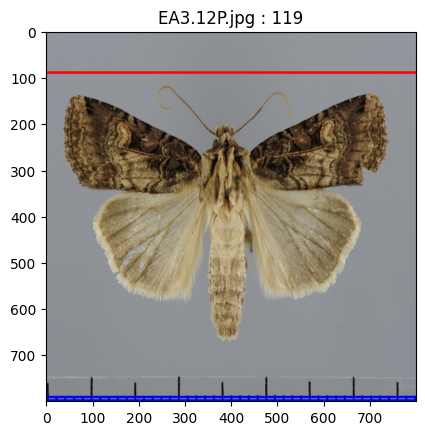

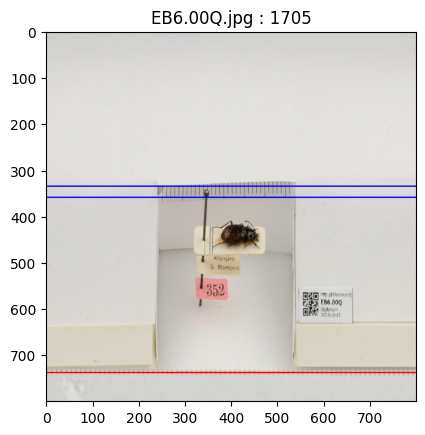

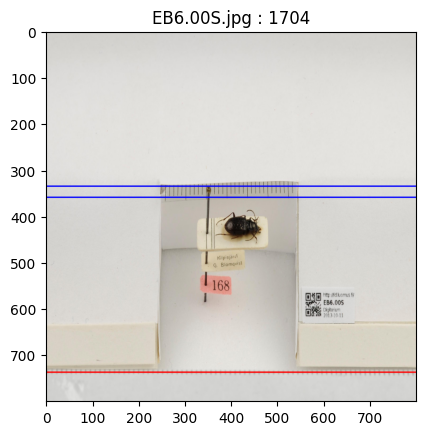

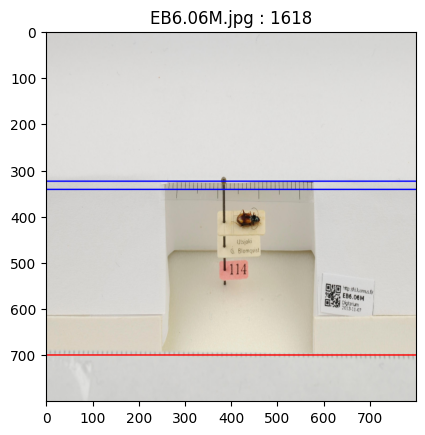

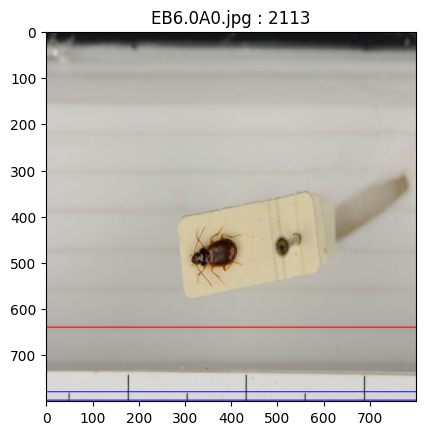

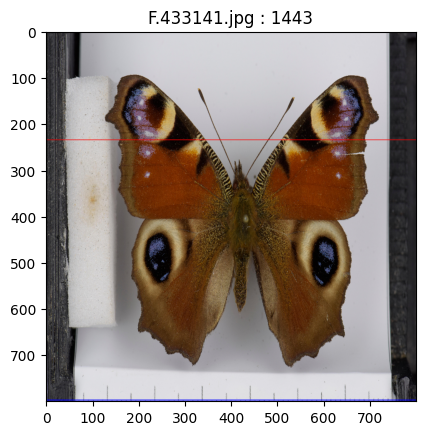

In [ ]:
# gallery of not good prediction and red line where it has been predicted, and blue lines between where it should be
not_correct = df[df["Correct"] == 0]["Name"].tolist()
print("total :", len(not_correct), " / ", len(df))
for image in not_correct:
    img = cv2.imread(str(IMG_PATH/image))
    value, line = detect_ruler(IMG_PATH/image, ratio=RATIO)
    max_line_coord = df.loc[df["Name"] == image, "Max"].iloc[0]
    min_line_coord = df.loc[df["Name"] == image, "Min"].iloc[0]
    cv2.line(img, (0, min_line_coord), (img.shape[1], min_line_coord), (255, 0, 0), 5)
    cv2.line(img, (0, max_line_coord), (img.shape[1], max_line_coord), (255, 0, 0), 5)
    if line is not None:
        cv2.line(img, (0, line), (img.shape[1], line), (0, 0, 255), 5)
    # scale the image to 800x800
    img = cv2.resize(img, (800, 800))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{image} : {line}")
    plt.show()


# with ratio of 5

In [ ]:
# run on every images and add the results to the dataframe
T3 = time.time()
base_results = []
base_failed = []
for image in tqdm.tqdm(images):
    value, line = detect_ruler(image)
    if line is not None:
        base_results.append(line)
    else:
        base_results.append("NaN")
        base_failed.append(image)
df["BASE_Predicted_line"] = base_results
print(base_failed)
T4 = time.time()
print(f"Time taken: {T4 - T3} seconds")

100%|██████████| 160/160 [02:56<00:00,  1.10s/it]

[]
Time taken: 176.02473664283752 seconds


In [ ]:
# calculate metrics : if predicted value is between "Min" and "Max", it is correct
df["Base_Correct"] = df["Predicted_line"].apply(lambda x: check(x, df))
print("Accuracy: ", df["Base_Correct"].mean())
print("Images not correctly detected: ", df[df["Base_Correct"] == 0]["Name"].tolist())

Accuracy:  0.9625
Images not correctly detected:  ['EA3.12P.jpg', 'EB6.00Q.jpg', 'EB6.00S.jpg', 'EB6.06M.jpg', 'EB6.0A0.jpg', 'F.433141.jpg']


total : 6  /  160


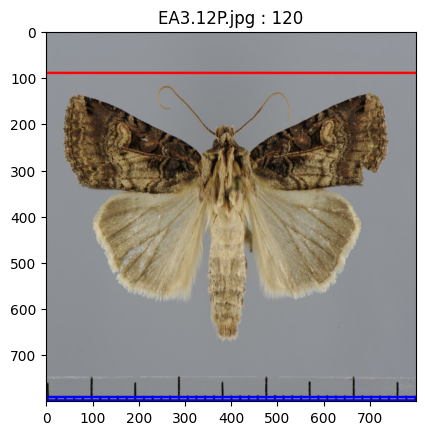

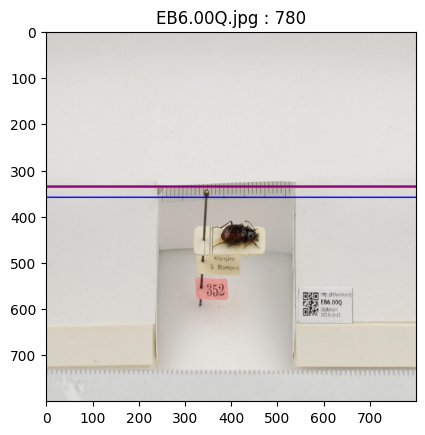

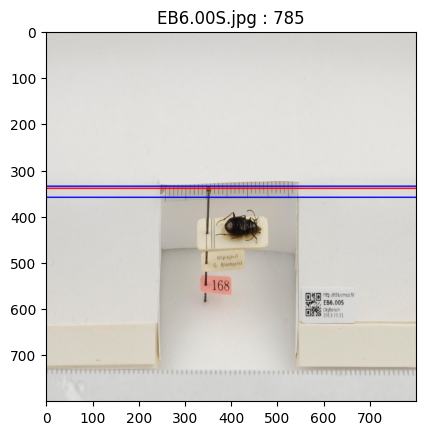

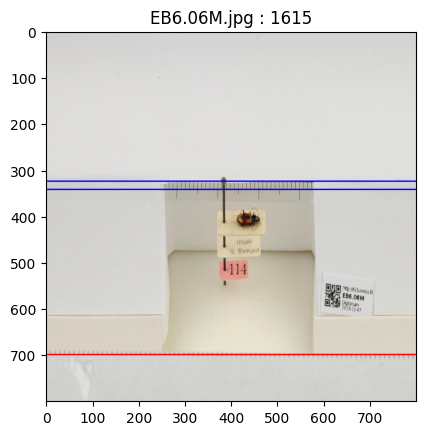

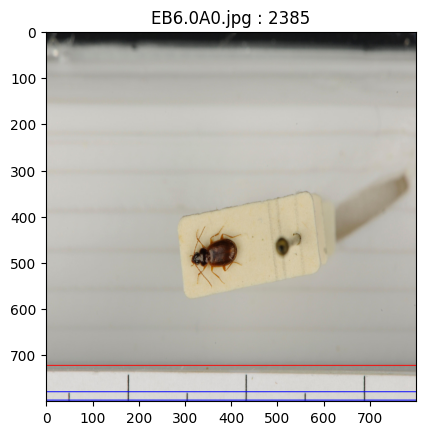

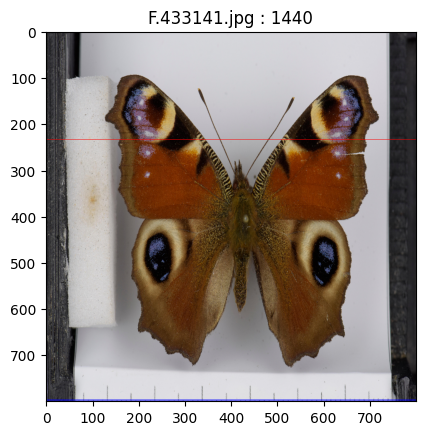

In [ ]:
# gallery of not good prediction and red line where it has been predicted, and blue lines between where it should be
base_not_correct = df[df["Base_Correct"] == 0]["Name"].tolist()
print("total :", len(base_not_correct), " / ", len(df))
for image in base_not_correct:
    img = cv2.imread(str(IMG_PATH/image))
    value, line = detect_ruler(IMG_PATH/image)
    max_line_coord = df.loc[df["Name"] == image, "Max"].iloc[0]
    min_line_coord = df.loc[df["Name"] == image, "Min"].iloc[0]
    cv2.line(img, (0, min_line_coord), (img.shape[1], min_line_coord), (255, 0, 0), 5)
    cv2.line(img, (0, max_line_coord), (img.shape[1], max_line_coord), (255, 0, 0), 5)
    if line is not None:
        cv2.line(img, (0, line), (img.shape[1], line), (0, 0, 255), 5)
    # scale the image to 800x800
    img = cv2.resize(img, (800, 800))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{image} : {line}")
    plt.show()


## ratio testing

In [4]:
ONLY_HORIZONTAL_RULER = True

def process_images(ratio, phase=0):
    predicted_lines = []
    ruler_confidences = []
    prediction_times = []
    image_sizes = []
    scale_values = []
    label_mins = []
    label_maxs = []
    directions = []

    for img in tqdm.tqdm(df["Name"]):
        if img in images:
            path = Path(path_images[images.index(img)])
            label_min, label_max = df[df["Name"] == img]["Min"].iloc[0], df[df["Name"] == img]["Max"].iloc[0]
            img_bgr = cv2.imread(str(path))
            shape = img_bgr.shape
            if img_bgr is None:
                raise ValueError(f"cv2 could not read image: {path}")
            rotated_img = np.rot90(img_bgr)

            T = time.time()
            px_per_mm_h, line_h, ruler_conf_h = detect_ruler_from_rgb(img_bgr, ratio=ratio, phase=phase)

            if not ONLY_HORIZONTAL_RULER:
                px_per_mm_v, line_v, ruler_conf_v = detect_ruler_from_rgb(rotated_img, ratio=ratio, phase=phase)
            else:
                px_per_mm_v, line_v, ruler_conf_v  = None, None, 0.0
                
            if ruler_conf_v is None or (ruler_conf_h is not None and ruler_conf_h > ruler_conf_v):
                px_per_mm, line, ruler_conf = px_per_mm_h, line_h, ruler_conf_h
                directions.append(1)
            elif ruler_conf_h is None or (ruler_conf_v is not None and ruler_conf_v > ruler_conf_h):
                px_per_mm, line, ruler_conf = px_per_mm_v, line_v, ruler_conf_v
                directions.append(0)
            else:
                print("Problem with ", path)
                directions.append(-1)

            predicted_lines.append(line if line is not None else -100)
            ruler_confidences.append(ruler_conf if ruler_conf is not None else 0)
            prediction_times.append(round(time.time() - T, 5))
            image_sizes.append(shape[0] * shape[1])
            scale_values.append(px_per_mm * (shape[0] if directions[-1]==1 else shape[1]) if px_per_mm is not None else 0)
            label_maxs.append(label_max)
            label_mins.append(label_min)
        else:
            print(img, "does not exists")
    return predicted_lines, ruler_confidences, prediction_times, image_sizes, scale_values, label_mins, label_maxs, directions



In [ ]:
all_ratios = [1, 2, 3, 5, 7, 8, 10]
data = {
    "all_lines" : [],
    "all_confs" : [],
    "all_times" : [],
    "all_sizes" : [],
    "all_scales" : [],
    "all_label_mins" : [],
    "all_label_maxs" : [],
    "all_directions" : [],
}
data_keys = list(data.keys())
#for ri in tqdm.tqdm(range(len(all_ratios)), colour="red"):
#    r = all_ratios[ri]
#    for d in data.keys():
#        data[d].append([])
 #   for p in tqdm.tqdm(range(r)):
 #       results = process_images(r, p)
  #      for di in range(len(data_keys)):
  #          data[data_keys[di]][ri].append(results[di])

print(data)

100%|██████████| 7/7 [00:00<00:00, 791.70it/s]

{'all_lines': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_confs': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_times': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_sizes': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_scales': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_label_mins': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_label_maxs': [[1], [1, 1], [1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'all_directions': [[1], [1, 1

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("evaluation.json") as f:
    data = json.load(f)

ratios = list(range(1, 11))       # doit correspondre a all_ratios
RATIO_REF = 5                     # ratio retenu pour la suite

def get(key, ri):
    """Retourne la liste des tableaux (un par phase) pour le ratio d'indice ri."""
    return [np.asarray(p, dtype=float) for p in data[key][ri]]

def plot_stat(values, label=None):
    """values[ri] = liste de scalaires, un par phase.
    Un point par phase + une ligne reliant la moyenne sur les phases."""
    xs = [r for ri, r in enumerate(ratios) for _ in values[ri]]
    ys = [v for ri, _ in enumerate(ratios) for v in values[ri]]
    means = [np.mean(v) for v in values]
    line, = plt.plot(ratios, means, marker="", label=label)
    plt.scatter(xs, ys, s=18, alpha=0.45, color=line.get_color())
    return line

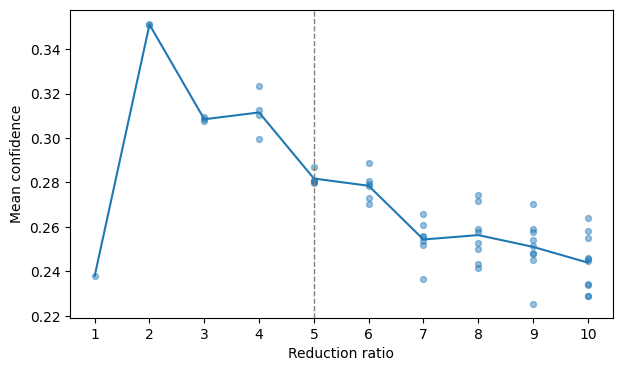

In [3]:
conf_by_ratio = [[c.mean() for c in get("all_confs", ri)] for ri in range(len(ratios))]

plt.figure(figsize=(7, 4))
plot_stat(conf_by_ratio)
plt.axvline(RATIO_REF, ls="--", lw=1, color="gray")
plt.xlabel("Reduction ratio")
plt.ylabel("Mean confidence")
plt.xticks(ratios)
plt.show()

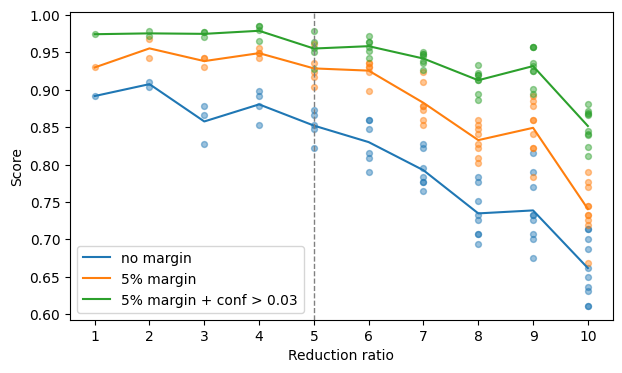

In [4]:
CONF_MIN = 0.03
scores = {"no margin": [], "5% margin": [], "5% margin + conf > 0.03": []}

for ri in range(len(ratios)):
    lines = get("all_lines", ri)
    confs = get("all_confs", ri)
    mins = get("all_label_mins", ri)
    maxs = get("all_label_maxs", ri)
    for k in scores:
        scores[k].append([])
    for ph in range(len(lines)):
        l, c, lo, hi = lines[ph], confs[ph], mins[ph], maxs[ph]
        ok_strict = (l >= lo) & (l <= hi)
        ok_margin = (l >= lo * 0.95) & (l <= hi * 1.05)
        kept = c > CONF_MIN
        scores["no margin"][ri].append(ok_strict.mean())
        scores["5% margin"][ri].append(ok_margin.mean())
        scores["5% margin + conf > 0.03"][ri].append(
            ok_margin[kept].mean() if kept.any() else np.nan)

plt.figure(figsize=(7, 4))
for k, v in scores.items():
    plot_stat(v, label=k)
plt.axvline(RATIO_REF, ls="--", lw=1, color="gray")
plt.xlabel("Reduction ratio")
plt.ylabel("Score")
plt.xticks(ratios)
plt.legend()
plt.show()

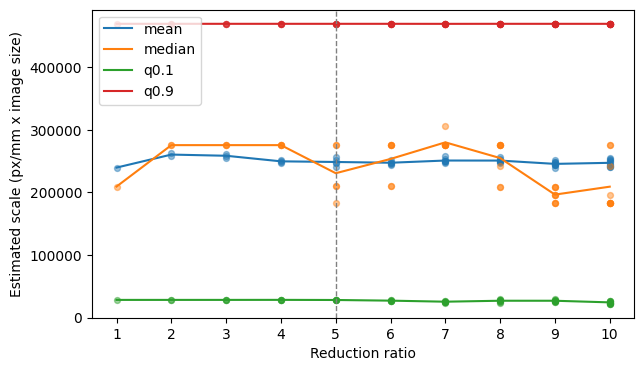

In [5]:
stats = {"mean": np.mean, "median": np.median,
         "q0.1": lambda x: np.quantile(x, 0.1),
         "q0.9": lambda x: np.quantile(x, 0.9)}
scale_stats = {k: [] for k in stats}

for ri in range(len(ratios)):
    for k in stats:
        scale_stats[k].append([])
    for s in get("all_scales", ri):
        s = s[s > 0]                      # 0 = pas de detection
        for k, fn in stats.items():
            scale_stats[k][ri].append(fn(s) if s.size else np.nan)

plt.figure(figsize=(7, 4))
for k, v in scale_stats.items():
    plot_stat(v, label=k)
plt.axvline(RATIO_REF, ls="--", lw=1, color="gray")
plt.xlabel("Reduction ratio")
plt.ylabel("Estimated scale (px/mm x image size)")
plt.xticks(ratios)
plt.legend()
plt.show()

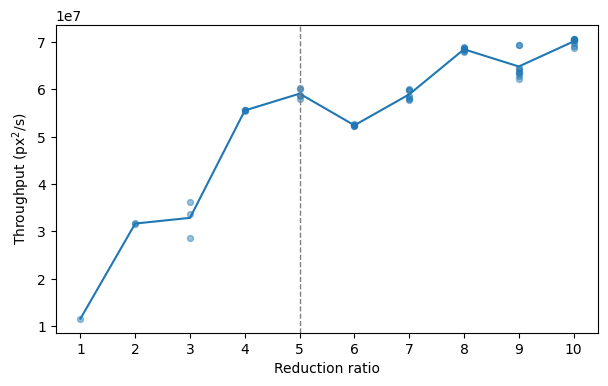

In [32]:
speed_by_ratio = []
for ri in range(len(ratios)):
    sizes = get("all_sizes", ri)
    times = get("all_times", ri)
    speed_by_ratio.append([s.sum() / t.sum()  for s, t in zip(sizes, times)])

plt.figure(figsize=(7, 4))
plot_stat(speed_by_ratio)
plt.axvline(RATIO_REF, ls="--", lw=1, color="gray")
plt.xlabel("Reduction ratio")
plt.ylabel("Throughput (px$^2$/s)")
plt.xticks(ratios)
plt.show()

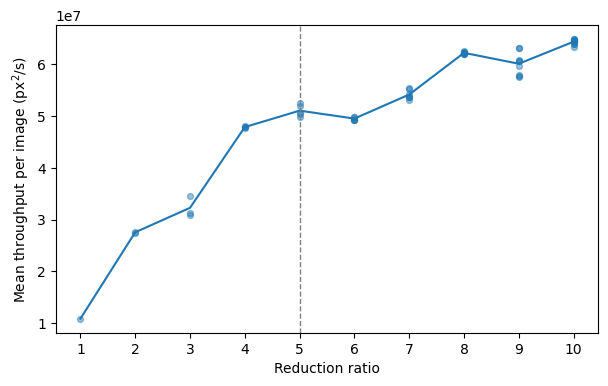

In [34]:
speed_by_ratio_unw = []
for ri in range(len(ratios)):
    sizes = get("all_sizes", ri)
    times = get("all_times", ri)
    speed_by_ratio_unw.append([])
    for s, t in zip(sizes, times):
        ok = t > 0
        speed_by_ratio_unw[ri].append(np.mean(s[ok] / t[ok]) if ok.any() else np.nan)

plt.figure(figsize=(7, 4))
plot_stat(speed_by_ratio_unw)
plt.axvline(RATIO_REF, ls="--", lw=1, color="gray")
plt.xlabel("Reduction ratio")
plt.ylabel("Mean throughput per image (px$^2$/s)")
plt.xticks(ratios)
plt.show()

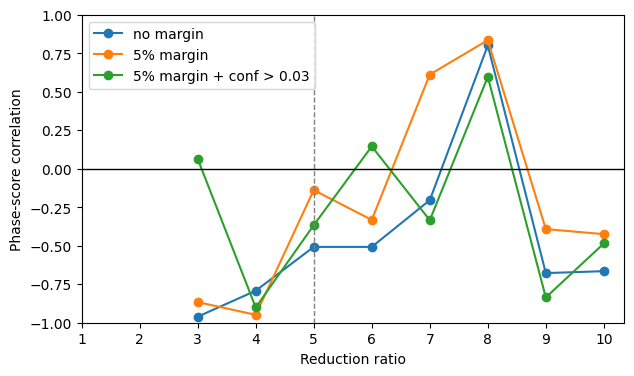

In [7]:
from scipy.stats import pearsonr

plt.figure(figsize=(7, 4))
for k, v in scores.items():
    corrs = []
    for ri in range(len(ratios)):
        s = np.asarray(v[ri], dtype=float)
        ph = np.arange(len(s), dtype=float)
        ok = np.isfinite(s)
        if ok.sum() < 3 or np.ptp(s[ok]) == 0:
            corrs.append(np.nan)
        else:
            corrs.append(pearsonr(ph[ok], s[ok])[0])
    plt.plot(ratios, corrs, marker="o", label=k)

plt.axvline(RATIO_REF, ls="--", lw=1, color="gray")
plt.axhline(0, lw=1, color="black")
plt.xlabel("Reduction ratio")
plt.ylabel("Phase-score correlation")
plt.xticks(ratios)
plt.ylim(-1, 1)
plt.legend()
plt.show()